# 1. Problema Preditivo

Este projeto tem como objetivo prever a variável `cognitive_performance_score`, que representa o desempenho cognitivo do indivíduo no dia seguinte, com base em informações relacionadas à qualidade do sono, hábitos de vida, indicadores fisiológicos e fatores comportamentais. 

Essa previsão é relevante para apoiar a identificação antecipada de fatores que impactam o desempenho cognitivo, possibilitando a adoção de estratégias para melhorar a qualidade do sono, o bem-estar e a produtividade, além de subsidiar decisões em contextos de saúde, pesquisa e desenvolvimento de soluções voltadas ao monitoramento da saúde do sono.

*OBS: O dataset utilizado neste projeto é sintético e contém 100 mil registros.*

# 2. Diretório Principal

In [1]:
import sys
from pathlib import Path


# Diretório atual
PROJECT_ROOT = Path.cwd() 

# Sobe um diretório por vez até encontrar a pasta ˜src˜.
while not (PROJECT_ROOT / "src").exists(): 
    PROJECT_ROOT = PROJECT_ROOT.parent  

# Se a pasta principal do projeto ainda não está na lista de locais onde se procura módulos, add
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# 3. Carregando o Dataset

In [2]:
from src.dataset import carregar_dataset

df = carregar_dataset()
df.head(5)

Dataset carregado: 100000 linhas x 32 colunas


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,3,0,0.0,32,0,6592,0,4.4,10.7,Morning,Healthy,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,4,0,0.0,33,1,10111,8,4.0,3.0,Neutral,Healthy,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,4,0,2.0,89,1,9222,28,7.8,3.6,Neutral,Both,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,4,0,1.0,52,1,9190,40,4.9,6.7,Morning,Healthy,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,5,40,0.0,72,0,4273,0,7.4,10.4,Neutral,Healthy,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


# 4. Fase 1: Análise Exploratória de Dados (EDA)

## 4.1. Estatística Descritiva

In [3]:
from src.eda import estatistica_descritiva

estatistica_descritiva(df)#

DIMENSÕES DO DATASET
Linhas : 100000
Colunas: 32


TIPOS DAS VARIÁVEIS
person_id                        int64
age                              int64
gender                          object
occupation                      object
bmi                            float64
country                         object
sleep_duration_hrs             float64
sleep_quality_score            float64
rem_percentage                 float64
deep_sleep_percentage          float64
sleep_latency_mins               int64
wake_episodes_per_night          int64
caffeine_mg_before_bed           int64
alcohol_units_before_bed       float64
screen_time_before_bed_mins      int64
exercise_day                     int64
steps_that_day                   int64
nap_duration_mins                int64
stress_score                   float64
work_hours_that_day            float64
chronotype                      object
mental_health_condition         object
heart_rate_resting_bpm           int64
sleep_aid_used                  

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,0.596800,63.539620,0.450710,7496.859740,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,1.059161,44.550502,0.497567,3460.423881,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,0.000000,2.000000,0.000000,500.000000,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,0.000000,30.000000,0.000000,5045.000000,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,0.000000,51.000000,0.000000,7442.000000,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,1.000000,84.000000,1.000000,9887.000000,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,6.000000,180.000000,1.000000,20000.000000,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


Os tipos de dados estão coerentes com seus respectivos valores. Portanto, não será necessário tratá-los.

A análise estatística descritiva mostra que o conjunto de dados possui 100.000 observações completas, sem valores ausentes nas variáveis numéricas. A variável-alvo (`cognitive_performance_score`) possui média de 59,23 e mediana de 60,40, sugerindo uma distribuição aproximadamente simétrica.

## 4.2. Visualização de Dados

Assimetria da variável-alvo: -0.29
Gráfico salvo em: /Users/jenifer/Documents/SCTEC-PROJETO-MD1/outputs/figures/distribuicao_variavel_alvo.png


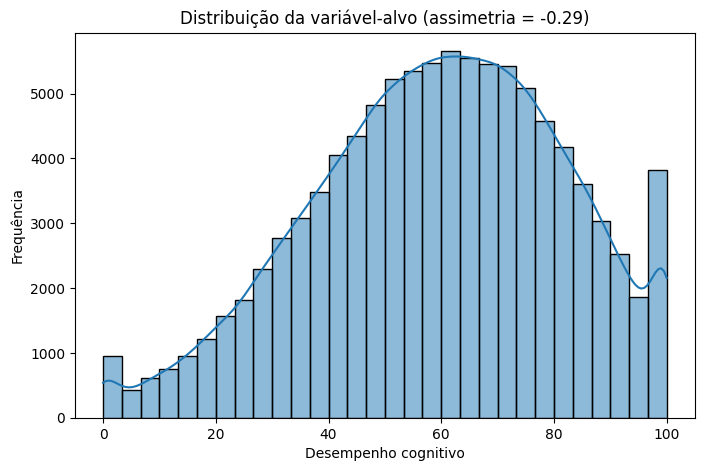

Gráfico salvo em: /Users/jenifer/Documents/SCTEC-PROJETO-MD1/outputs/figures/qualidade_sono_desempenho.png


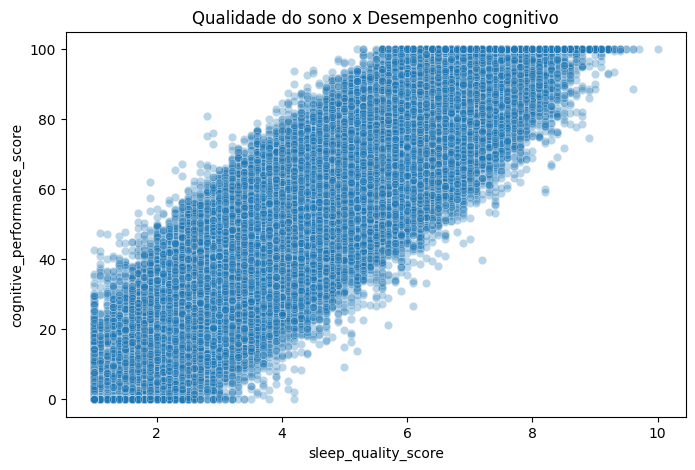

Gráfico salvo em: /Users/jenifer/Documents/SCTEC-PROJETO-MD1/outputs/figures/estresse_desempenho.png


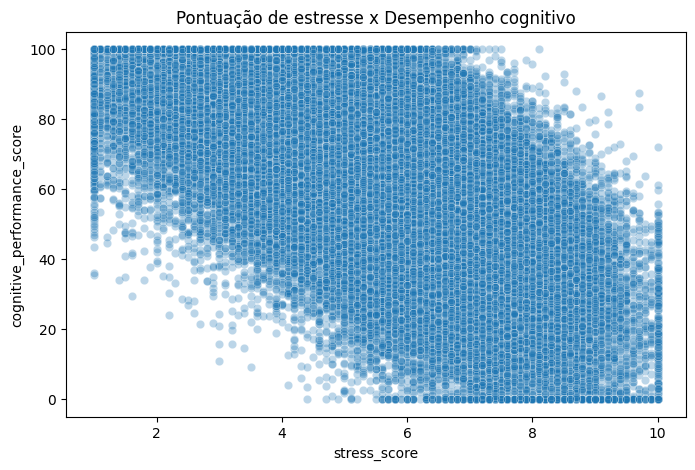

Gráfico salvo em: /Users/jenifer/Documents/SCTEC-PROJETO-MD1/outputs/figures/correlacao_pearson.png


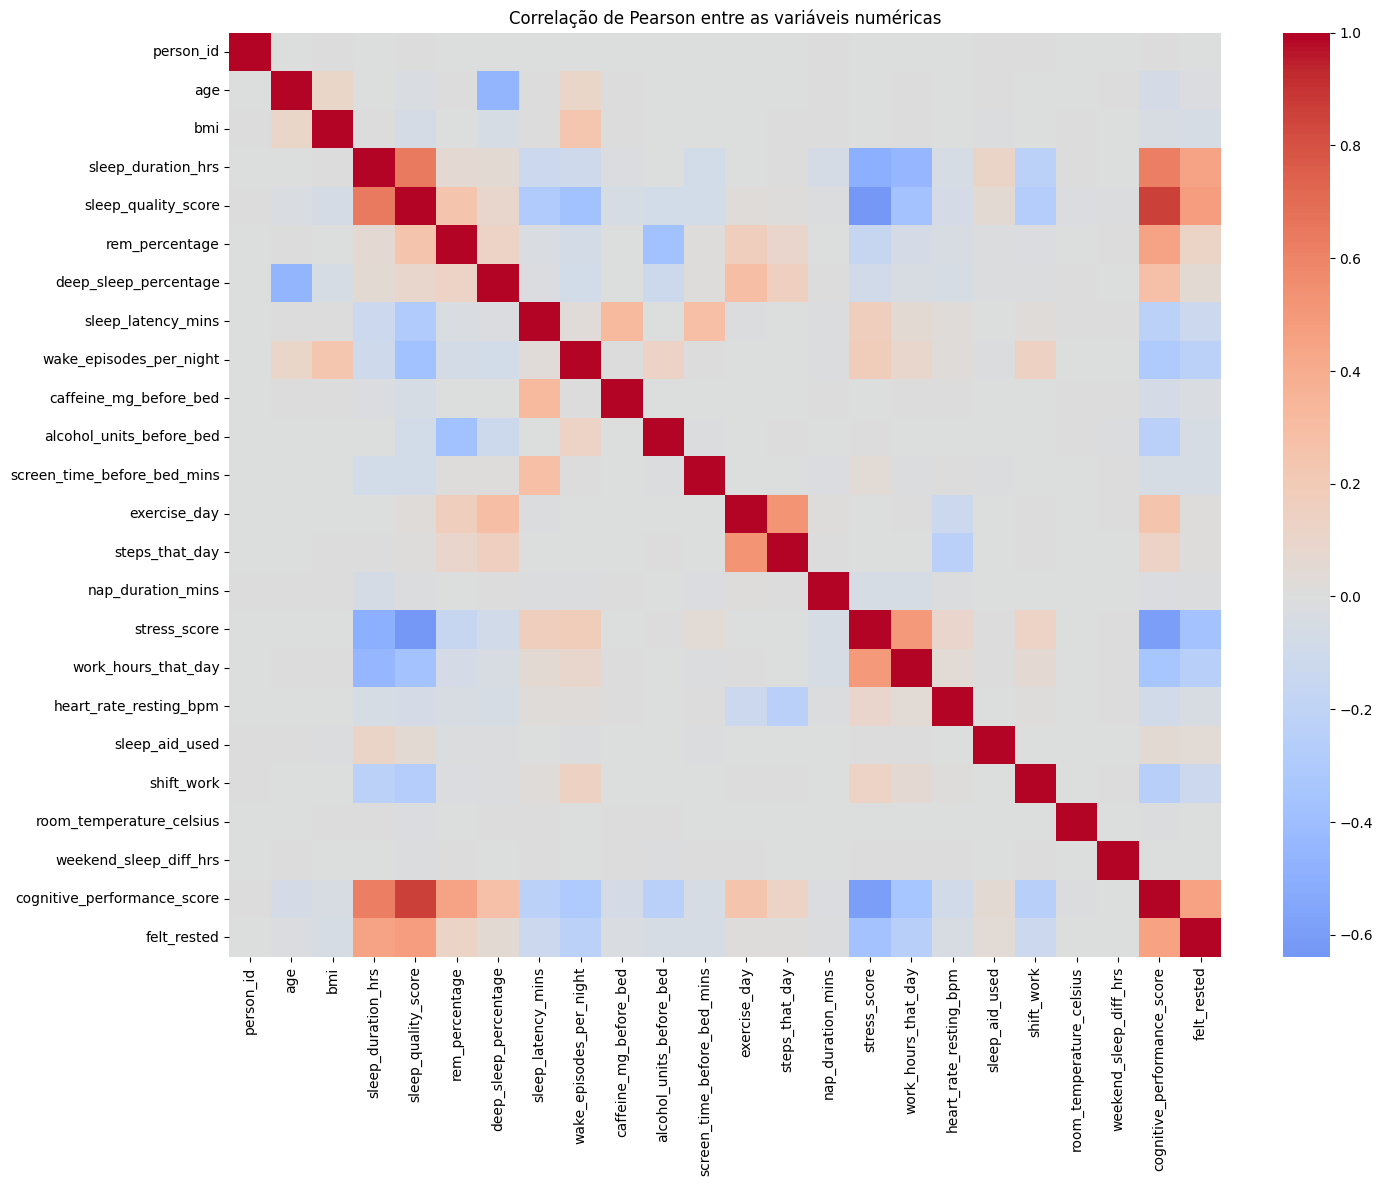

Pares com correlação > 0.7:
sleep_quality_score  cognitive_performance_score    0.859978
dtype: float64


In [4]:
from src.eda import visualizar_dados

visualizar_dados(df)

### Histograma de distribuição da variável-alvo

A variável-alvo apresenta distribuição aproximadamente simétrica, com leve assimetria negativa (−0,29), concentrando a maior parte dos valores entre 50 e 80 pontos. Essa característica é favorável para modelos de regressão.

---

### Gráficos de dispersão entre variáveis explicativas e a variável-alvo

**Qualidade do sono × Desempenho cognitivo:** relação positiva, indicando que maiores valores de qualidade do sono tendem a estar associados a um melhor desempenho cognitivo.

**Estresse × Desempenho cognitivo:** relação negativa, sugerindo que maiores níveis de estresse tendem a estar associados a um menor desempenho cognitivo.

---

### Mapa de calor da correlação de Pearson

O mapa de calor evidencia que a variável-alvo apresenta correlação positiva principalmente com a qualidade (muito forte -> 0,85) e a duração do sono, e correlação negativa com o estresse e as horas de trabalho. Além disso, as variáveis explicativas apresentam, em geral, correlações de baixa a moderada intensidade, não sendo observados indícios de multicolinearidade significativa.

## 4.3. Remoção de Coluna

(Removida a coluna **person_id** antes do tratamento e limpeza por motivos de antecipação ao cálculo do VIF mais abaixo)

Esta coluna não contribui no resultado final.

In [5]:
from src.preprocessing import remover_colunas

df = remover_colunas(df, ["person_id"])

df.head(5)

Colunas removidas: person_id


,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,3,0,0.0,32,0,6592,0,4.4,10.7,Morning,Healthy,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,4,0,0.0,33,1,10111,8,4.0,3.0,Neutral,Healthy,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,4,0,2.0,89,1,9222,28,7.8,3.6,Neutral,Both,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,4,0,1.0,52,1,9190,40,4.9,6.7,Morning,Healthy,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,5,40,0.0,72,0,4273,0,7.4,10.4,Neutral,Healthy,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


## 4.4. Reforçando Verificação de Existência de Multicolinearidade

In [6]:
from src.eda import calcular_vif

vif = calcular_vif(df, variavel_alvo="cognitive_performance_score")
display(vif)

,Variável,VIF
0,sleep_quality_score,3.203393
1,sleep_duration_hrs,2.166146
2,stress_score,2.011884
3,exercise_day,1.537679
4,deep_sleep_percentage,1.482077
5,steps_that_day,1.438819
6,work_hours_that_day,1.438156
7,felt_rested,1.373080
8,sleep_latency_mins,1.372979
9,wake_episodes_per_night,1.358664


> "Regra prática: VIF acima de **5** já pede atenção; acima de **10** indica redundância séria."

Como não há nenhum VIF acima de 5, não há variável que necessite de atenção em relação a multicolinearidade.

# 5. Fase 2: Tratamento e Limpeza (Data Prep)

## 5.1. Linhas Duplicadas

In [7]:
from src.preprocessing import verificar_duplicados

verificar_duplicados(df)

VERIFICAÇÃO DE DUPLICADOS
Registros duplicados: 0


np.int64(0)

Não há registros duplicados. Logo, não há necessidade de tratá-los.

## 5.2. Valores Ausentes (Missing Data)

In [8]:
from src.preprocessing import verificar_valores_ausentes

verificar_valores_ausentes(df)

VERIFICAÇÃO DE VALORES AUSENTES
Não há valores ausentes no conjunto de dados.


,Valores Ausentes,Percentual (%)


Não há valores ausentes. Logo, não há necessidade de tratá-los.

## 5.3. Gerenciamento de Outliers

Gráfico salvo em: /Users/jenifer/Documents/SCTEC-PROJETO-MD1/outputs/figures/boxplots_variaveis_explicativas.png


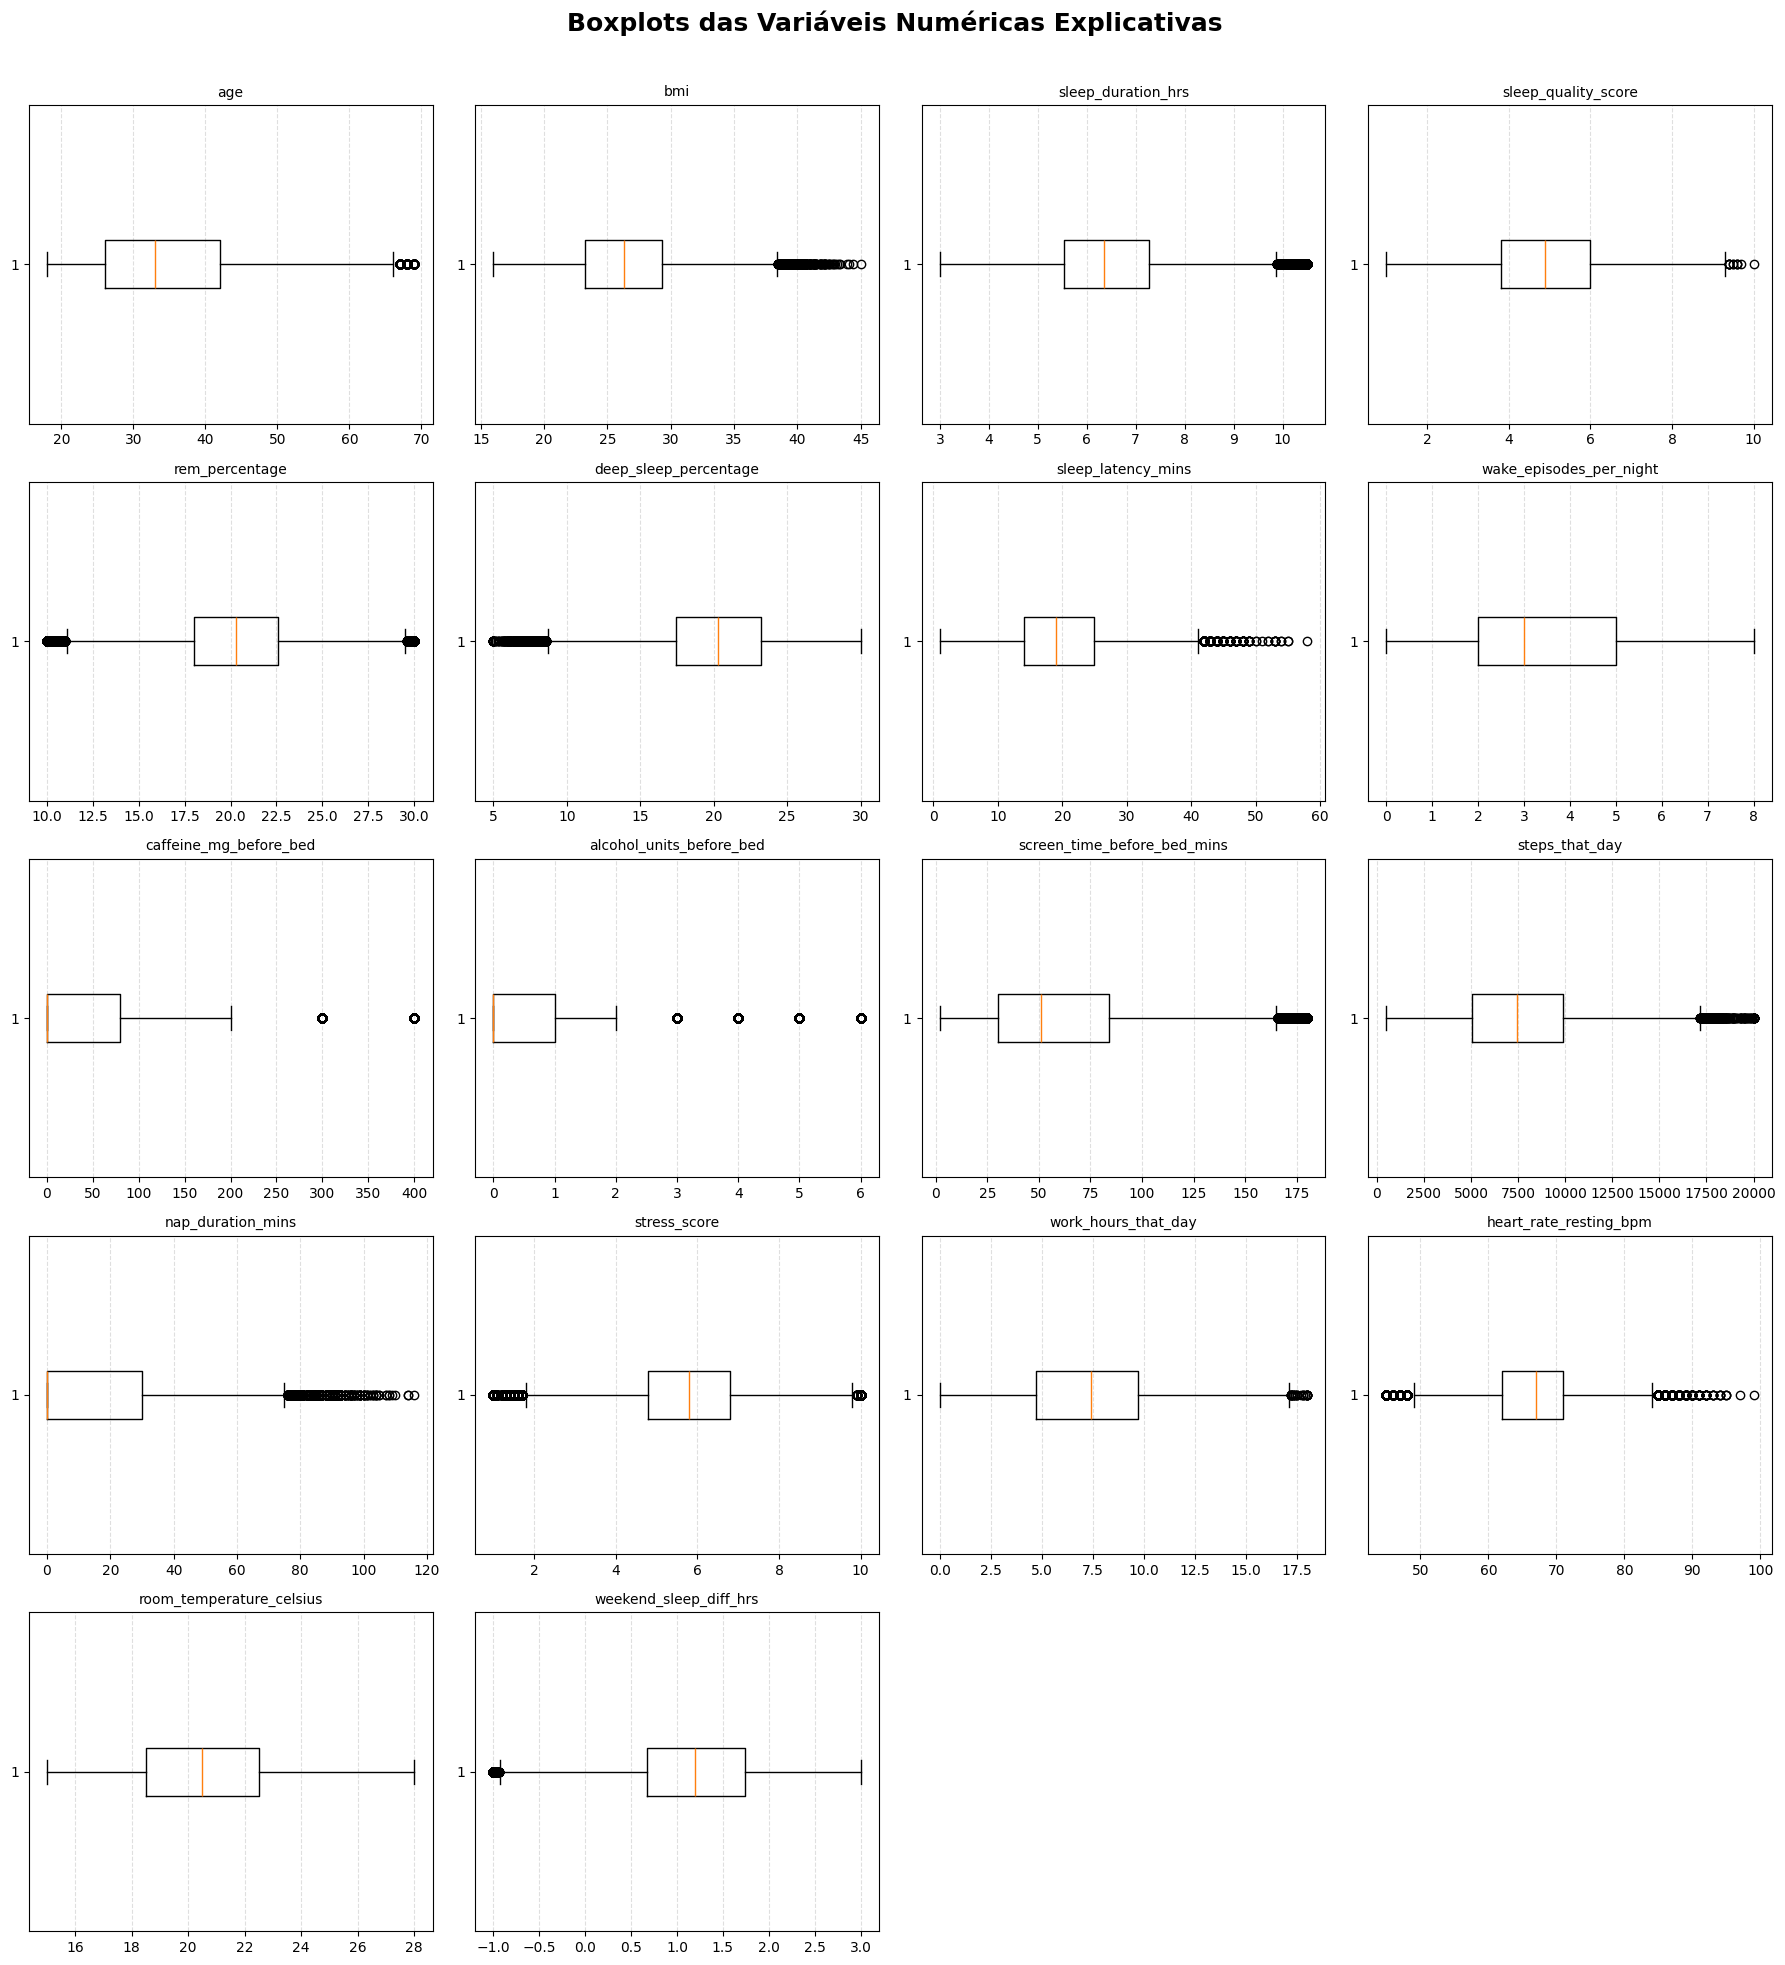

In [9]:
from src.preprocessing import plotar_boxplots

plotar_boxplots(df, variavel_alvo="cognitive_performance_score")

Os boxplots indicaram valores extremos em algumas variáveis explicativas. Como a análise não indicou erros de medição nem valores impossíveis, optou-se por mantê-los para preservar a representatividade da base de dados. Embora a Regressão Linear seja sensível a valores extremos, as métricas semelhantes entre treino e teste e a distribuição dos resíduos indicam que esses valores não comprometeram significativamente a capacidade de generalização do modelo.

# 6. Fase 3: Feature Engineering (Coluna Calculada)

Criação da variável `recovery_score`, calculada pela diferença entre a qualidade do sono (`sleep_quality_score`) e o nível de estresse (`stress_score`). Lembrando que ambas as variáveis possuem range de 0 a 10.

- (+) → qualidade do sono maior que o estresse;

-   0 → qualidade do sono e estresse equivalentes;

- (-) → estresse maior que a qualidade do sono.


O objetivo é representar o equilíbrio entre recuperação física/mental e o fator de desgaste estresse.

In [10]:
df["recovery_score"] = (df["sleep_quality_score"] - df["stress_score"]) # Cria nova coluna

In [11]:
df.head(5)

,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested,recovery_score
0,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,3,0,0.0,32,0,6592,0,4.4,10.7,Morning,Healthy,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0,2.2
1,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,4,0,0.0,33,1,10111,8,4.0,3.0,Neutral,Healthy,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1,2.9
2,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,4,0,2.0,89,1,9222,28,7.8,3.6,Neutral,Both,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0,-6.8
3,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,4,0,1.0,52,1,9190,40,4.9,6.7,Morning,Healthy,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0,1.5
4,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,5,40,0.0,72,0,4273,0,7.4,10.4,Neutral,Healthy,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0,-4.2


In [12]:
# Visualização com a nova coluna
df[["sleep_quality_score", "stress_score", "recovery_score", "cognitive_performance_score"]].head(10)

,sleep_quality_score,stress_score,recovery_score,cognitive_performance_score
0,6.6,4.4,2.2,73.4
1,6.9,4.0,2.9,99.4
2,1.0,7.8,-6.8,2.5
3,6.4,4.9,1.5,67.8
4,3.2,7.4,-4.2,38.1
5,5.7,5.5,0.2,49.9
6,5.1,5.0,0.1,57.9
7,6.5,5.5,1.0,92.0
8,5.4,6.0,-0.6,53.6
9,4.9,5.7,-0.8,67.8


In [13]:
vif = calcular_vif(df, variavel_alvo="cognitive_performance_score")
display(vif)

/Users/jenifer/Documents/SCTEC-PROJETO-MD1/.venv/lib/python3.9/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Variável,VIF
0,recovery_score,inf
1,stress_score,inf
2,sleep_quality_score,inf
3,sleep_duration_hrs,2.166146
4,exercise_day,1.537679
5,deep_sleep_percentage,1.482077
6,steps_that_day,1.438819
7,work_hours_that_day,1.438156
8,felt_rested,1.373080
9,sleep_latency_mins,1.372979


Nota-se acima que a nova coluna `recovery_score` **gerou multicolinearidade perfeita**. 

In [14]:
df = remover_colunas(df, ["sleep_quality_score", "stress_score"])

Colunas removidas: sleep_quality_score, stress_score


Como a nova variável  `recovery_score` é calculada diretamente a partir dessas duas variáveis, `sleep_quality_score` e `stress_score`, elas foram removidas do conjunto de preditores para remover a multicolinearidade perfeita criada e tornar o modelo mais estável.

In [15]:
from src.dataset import salvar_dataset_processado

salvar_dataset_processado(df, versao="v1")

Dataset processado salvo em: /Users/jenifer/Documents/SCTEC-PROJETO-MD1/data/processed/dataset_processado_v1.csv


Visualiza multicolinearidade novamente:

In [16]:
vif = calcular_vif(df, variavel_alvo="cognitive_performance_score")
display(vif)

,Variável,VIF
0,recovery_score,2.396286
1,sleep_duration_hrs,1.976813
2,exercise_day,1.537332
3,deep_sleep_percentage,1.479784
4,steps_that_day,1.438761
5,work_hours_that_day,1.387314
6,felt_rested,1.366207
7,age,1.337177
8,sleep_latency_mins,1.327493
9,rem_percentage,1.292221


# 7. Fase 4: Preparação para Modelagem

Salva df final que será usado para modelagem.

In [17]:
from src.dataset import salvar_dataset_final

salvar_dataset_final(df, versao="v1")

Dataset final salvo em: /Users/jenifer/Documents/SCTEC-PROJETO-MD1/data/final/dataset_final_v1.csv


Divide conjunto de dados em treino (80%) e teste (20%).

In [18]:
from src.modeling import dividir_treino_teste

X_train, X_test, y_train, y_test = dividir_treino_teste(df, variavel_alvo="cognitive_performance_score", test_size=0.2, random_state=42)

DIVISÃO TREINO/TESTE
Tamanho do treino: 80000
Tamanho do teste : 20000


# 8. Fase 5: Modelagem, Validação e Diagnóstico de Overfitting

## 8.1. Treinamento e Testes

As variáveis categóricas serão tratadas com One-Hot Encoding, utilizando `drop="first"` para evitar redundância entre as categorias e `handle_unknown="ignore"` para permitir categorias não observadas no treino.

As variáveis numéricas serão padronizadas com StandardScaler. O pré-processamento foi inserido em uma Pipeline, garantindo que os parâmetros do escalonamento sejam ajustados apenas com o conjunto de treino e posteriormente aplicados ao conjunto de teste, evitando vazamento de dados.

In [19]:
from src.modeling import treinar_e_testar_regressao_linear

modelo_rl, y_pred = treinar_e_testar_regressao_linear(X_train, y_train, X_test)

Apenas visualizando algumas previsões (real/previsto):

In [20]:
import pandas as pd

resultado = pd.DataFrame({"Valor Real": y_test.values, "Valor Previsto": y_pred})

resultado.head(10)

,Valor Real,Valor Previsto
0,57.2,58.906648
1,17.8,14.511616
2,49.2,52.940192
3,38.0,40.455800
4,33.5,39.418571
5,75.2,69.371897
6,72.9,76.075461
7,31.1,34.595330
8,70.8,66.001462
9,60.5,58.143863


## 8.2. Métricas Técnicas: Comparação Treino e Teste

Comparando métricas nos conjuntos de treino e teste:

In [21]:
from src.modeling import comparar_metricas_treino_teste

comparacao_metricas = comparar_metricas_treino_teste(modelo_rl, X_train, y_train, X_test, y_test)

display(comparacao_metricas)

/Users/jenifer/Documents/SCTEC-PROJETO-MD1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jenifer/Documents/SCTEC-PROJETO-MD1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jenifer/Documents/SCTEC-PROJETO-MD1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jenifer/Documents/SCTEC-PROJETO-MD1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/jenifer/Documents/SCTEC-PROJETO-MD1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Us

,Treino,Teste,Diferença
MAE,5.969531,6.017255,0.047724
MSE,57.452508,58.616692,1.164184
RMSE,7.579743,7.656154,0.076411
R2,0.884156,0.880720,-0.003436


> As métricas obtidas nos conjuntos de treino e teste foram muito semelhantes, indicando que o modelo apresentou boa capacidade de generalização. As diferenças observadas foram pequenas (MAE: 0,047; RMSE: 0,076; R²: -0,003), não havendo evidências de overfitting. Isso demonstra que o modelo mantém desempenho consistente ao realizar previsões em dados não utilizados durante o treinamento.

# 9. Fase 6: Avaliação, Interpretação e Versionamento do Modelo

## 9.1. Métricas Técnicas para Conjunto de Teste

In [22]:
from src.modeling import avaliar_modelo

metricas_teste = avaliar_modelo(y_test, y_pred)

print("=" * 60)
print("MÉTRICAS DA REGRESSÃO LINEAR - CONJUNTO TESTE")
print("=" * 60)

for nome, valor in metricas_teste.items():
    print(f"{nome}: {valor:.4f}")

MÉTRICAS DA REGRESSÃO LINEAR - CONJUNTO TESTE
MAE: 6.0173
MSE: 58.6167
RMSE: 7.6562
R2: 0.8807


O modelo erra, em média, cerca de 6 pontos na previsão do desempenho cognitivo.

O R² foi de 0,8807, o que significa que o modelo explica cerca de 88,07% da variabilidade da variável-alvo.

Como o RMSE é apenas um pouco maior que o MAE, isso indica que não existem muitos erros extremamente grandes nas previsões, isto é, os erros do modelo são relativamente uniformes. Se o RMSE fosse muito maior que o MAE, seria um indício de que alguns casos apresentam erros bastante elevados.

## 9.2. Visualização de Valores Reais/Previstos e Resíduos

Gráfico salvo em: /Users/jenifer/Documents/SCTEC-PROJETO-MD1/outputs/figures/valores_reais_previstos.png


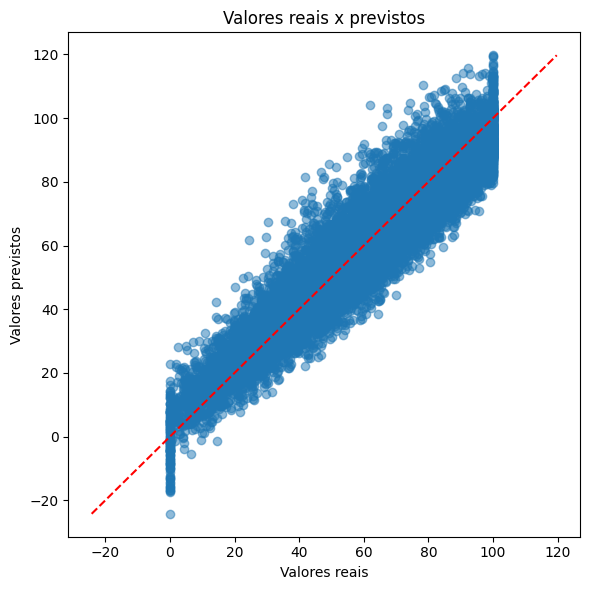

Gráfico salvo em: /Users/jenifer/Documents/SCTEC-PROJETO-MD1/outputs/figures/distribuicao_residuos.png


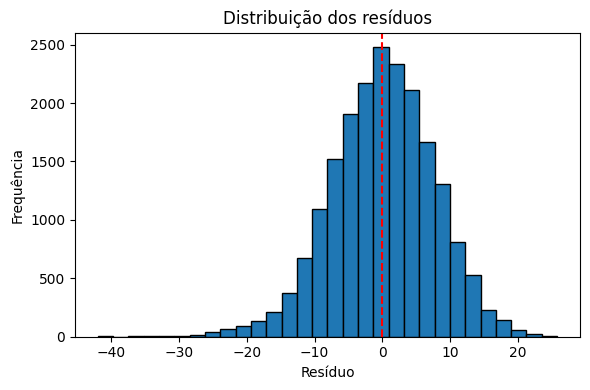

In [23]:
from src.modeling import plotar_valores_reais_previstos, plotar_residuos

plotar_valores_reais_previstos(y_test, y_pred)
plotar_residuos(y_test, y_pred)

**Valores reais  x Previstos**: Os pontos estão próximos da linha de referência (linha vermelha), indicando que, na maioria dos casos, as previsões ficaram próximas dos valores reais.

**Resíduos**: Os resíduos estão concentrados próximos de zero, no qual tem uma distribuição próxima de uma normal (sino).

Portanto, há um bom desempenho no modelo.

## 9.3. Veredito de Negócios

> O modelo apresentou um MAE de 6, ou seja, um erro médio de aproximadamente 6 pontos representa cerca de 6% da escala (0–100). Além disso, o R² de 0,8807 indica que o modelo explica aproximadamente 88% da variação dos dados. Dessa forma, o modelo apresenta um bom desempenho e pode ser utilizado como **apoio na análise** da relação entre sono, estilo de vida e desempenho cognitivo, mas **não deve substituir uma avaliação clínica**.

## 9.4. Versionamento do Modelo

Agora, treina o modelo com a base de dados completa e salva modelo e métricas de teste.

In [24]:
from src.modeling import salvar_modelo

X = df.drop(columns=["cognitive_performance_score"]) # Variáveis explicativas
y = df["cognitive_performance_score"] # Variável alvo

modelo_final, _ = treinar_e_testar_regressao_linear(X, y, X) # Treina com a base completa

salvar_modelo(modelo=modelo_final, metricas=metricas_teste, variaveis_explicativas=X.columns.tolist())

Modelo salvo na versão v1.
Modelo: /Users/jenifer/Documents/SCTEC-PROJETO-MD1/models/v1/modelo_regressao_v1.pkl
Métricas: /Users/jenifer/Documents/SCTEC-PROJETO-MD1/models/v1/metricas_v1.json
